# Лабораторная работа №2

## Датасет

In [9]:
import pandas as pd
import seaborn as sns

df = pd.read_csv("dataset.csv")
print(df.columns)

Index(['model', 'launchDate', 'numCores', 'numThreads', 'baseClock',
       'maxboostClock', 'allCoreBoostSpeed', 'L1Cache', 'L2Cache', 'L3Cache',
       'processTech', 'PCIeVersion', 'PCIeLanes', 'defaultTDP', 'configTDP',
       'tjMax', 'sysMemType', 'sysMemSpecs', 'memChannels', 'perSocketMemBW',
       'graphicsCores', 'graphicsFreq', 'unlocked', 'platform', 'cpuSocket',
       'socketCount', 'family', 'line', 'graphicsModel', 'thermalSolution'],
      dtype='str')


In [10]:
df

,model,launchDate,numCores,numThreads,baseClock,maxboostClock,allCoreBoostSpeed,L1Cache,L2Cache,L3Cache,...,graphicsCores,graphicsFreq,unlocked,platform,cpuSocket,socketCount,family,line,graphicsModel,thermalSolution
0,AMD Ryzen™ 5 6600H,2022.0,6.0,12.0,3.3,4.5,NaN,384.0,3.0,16.0,...,6.0,1900.0,No,Laptop,FP7,NaN,AMD Ryzen™ Processors,AMD Ryzen™ 5 Mobile Processors with Radeon™ Gr...,AMD Radeon™ 660M,NaN
1,AMD Ryzen™ 5 6600HS​,2022.0,6.0,12.0,3.3,4.5,NaN,384.0,3.0,16.0,...,6.0,1900.0,No,Laptop,FP7,NaN,AMD Ryzen™ Processors,AMD Ryzen™ 5 Mobile Processors with Radeon™ Gr...,AMD Radeon™ 660M,NaN
2,AMD Ryzen™ 5 6600U,2022.0,6.0,12.0,2.9,4.5,NaN,384.0,3.0,16.0,...,6.0,1900.0,No,Laptop,FP7,NaN,AMD Ryzen™ Processors,AMD Ryzen™ 5 Mobile Processors with Radeon™ Gr...,AMD Radeon™ 660M,NaN
3,AMD Ryzen™ 5 PRO 6650H,2022.0,6.0,12.0,3.3,4.5,NaN,384.0,3.0,16.0,...,6.0,1900.0,No,Laptop,NaN,NaN,AMD Ryzen™ PRO Processors,AMD Ryzen™ 5 PRO 6000 Series Mobile Processors,AMD Radeon™ 660M,NaN
4,AMD Ryzen™ 5 PRO 6650HS,2022.0,6.0,12.0,3.3,4.5,NaN,384.0,3.0,16.0,...,6.0,1900.0,No,Laptop,NaN,NaN,AMD Ryzen™ PRO Processors,AMD Ryzen™ 5 PRO 6000 Series Mobile Processors,AMD Radeon™ 660M,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
577,TL-56,NaN,NaN,NaN,1.8,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,No,Laptop,S1,NaN,AMD Turion™,AMD Turion™ 64 X2 Dual-Core Mobile Technology,NaN,NaN
578,TL-60,NaN,2.0,2.0,2.0,NaN,NaN,NaN,1.0,NaN,...,NaN,NaN,No,Laptop,S1,NaN,AMD Turion™,AMD Turion™ 64 X2 Dual-Core Mobile Technology,NaN,NaN
579,TL-64,NaN,2.0,2.0,2.2,NaN,NaN,NaN,1.0,NaN,...,NaN,NaN,No,Laptop,S1,NaN,AMD Turion™,AMD Turion™ 64 X2 Dual-Core Mobile Technology,NaN,NaN
580,X1150,NaN,4.0,4.0,2.0,NaN,NaN,NaN,2.0,NaN,...,NaN,NaN,No,Server,FT3,NaN,AMD Opteron™,AMD Opteron™ X1100 Series Processors,NaN,NaN


## Разбиение на train/test  

In [11]:
from sklearn.model_selection import train_test_split


SEED=4323245

df = df.dropna(subset=['defaultTDP'])
num_features = ['numCores', 'baseClock', 'L2Cache', 'sysMemSpecs']
cat_features = ['platform']
features = num_features + cat_features

X = df.drop(columns='defaultTDP')
y = df['defaultTDP']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)


## Базовая модель

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

lin_reg = LinearRegression()


# drop=first чтобы убрать мультиколлинеарность у кат признаков
encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

cat_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', encoder)
     ])

lin_transformer = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), num_features),
        ('cat', cat_pipeline, cat_features)
    ],
)

lin_model = Pipeline([
    ('transformer', lin_transformer),
    ('regressor', lin_reg)
])



lin_model.fit(X_train, y_train)



,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('transformer', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](29,)","['model','launchDate','numCores',...,'line','graphicsModel', 'thermalSolution']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,29
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset

In [13]:
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error, mean_absolute_error

def calc_metrics(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    return rmse, mae, r2

## Метрики базовой модели

In [14]:

base_metrics = pd.DataFrame([calc_metrics(y_train, lin_model.predict(X_train)),
                         calc_metrics(y_test, lin_model.predict(X_test))],
                        index=['train', 'test'], columns=['RMSE', 'MAE', 'R2']).round(2)
base_metrics

,RMSE,MAE,R2
train,29.99,20.87,0.77
test,37.67,25.35,0.74


## Кросс-валидация

### для запуска кроссвалидации и графиков

In [15]:
from matplotlib import pyplot as plt
from sklearn.base import clone

cv_results = {}

def cross_validation(cv, cv_name, X, y, cv_results_dict, groups = None, strat = None):
    splits = []
    rows = []
    cv_split = cv.split(X, y if strat is None else strat, groups)

    for train, val in cv_split:
        model = clone(lin_model).fit(X.iloc[train], y.iloc[train])
        y_pred = model.predict(X.iloc[val])
        metrics = calc_metrics(y.iloc[val], y_pred)
        test_rmse = calc_metrics(y_test, model.predict(X_test))[0]
        rows.append(metrics + (test_rmse,))
        splits.append((train, val))

    res = pd.DataFrame(rows, columns=['RMSE', 'MAE', 'R2', 'TEST_RMSE'])
    print(cv_name)
    print()
    print(res.round(2))
    print()
    print(pd.DataFrame({'mean': res.mean(), 'std': res.std(ddof=0)}).round(2).T)
    if cv_results_dict is not None:
        cv_results_dict[cv_name] = res
    return res, splits

def plot_cv(splits, y, cv_name):
    sns.set_style('whitegrid')
    fig, ax = plt.subplots(1, 2, figsize=(18, 4), gridspec_kw={'width_ratios': [3, 1]})

    for i, (train, val) in enumerate(splits):
        ax[0].scatter(train, [i] * len(train), marker='|', s=300, c='gold', label='train' if i == 0 else None)
        ax[0].scatter(val, [i] * len(val), marker='|', s=300, c='black', label='val' if i == 0 else None)
    
        sns.histplot(y.iloc[val], ax=ax[1], color='orange', label='val' if i == 0 else None, kde=True, alpha=0.3, stat='density')
        
    sns.histplot(y_test, ax=ax[1], color='blue', label='test', kde=True, alpha=0.3, stat='density')
    ax[0].set(title=cv_name, xlabel='номер строки', ylabel='Итерация', yticks=range(len(splits)))
    ax[1].set(title='Распределение TDP', xlabel='TDP')
    ax[0].legend(loc='lower right', bbox_to_anchor=(1, 1), ncol=2)
    ax[1].legend()


### 1. K-Fold - No shuffle

KFold - no shuffle

    RMSE    MAE    R2  TEST_RMSE
0  37.40  31.06  0.77      38.16
1  27.24  17.09  0.75      37.57
2  71.17  56.47 -2.94      39.77
3  25.65  17.68  0.67      37.95
4  42.73  30.58  0.72      39.44

       RMSE    MAE    R2  TEST_RMSE
mean  40.84  30.58 -0.01      38.58
std   16.44  14.28  1.47       0.87


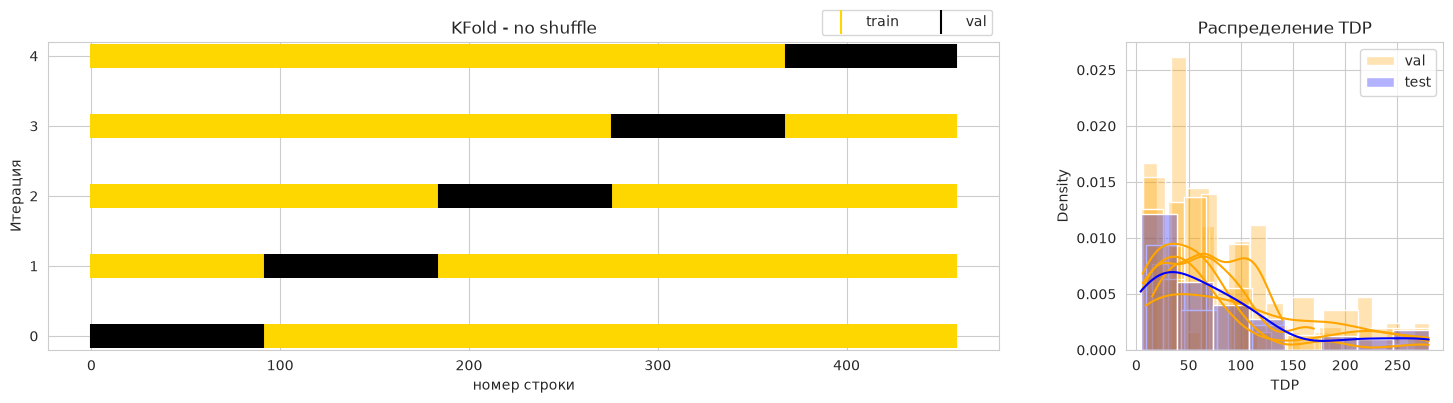

In [16]:
from sklearn.model_selection import KFold

X_sorted = X_train.sort_index() 
y_sorted = y_train.loc[X_sorted.index]


cv = KFold(n_splits=5)
cv_name = 'KFold - no shuffle'

res, splits = cross_validation(cv, cv_name, X_sorted, y_sorted, cv_results)
plot_cv(splits, y_sorted, cv_name)


### 2. K-Fold - shuffle

KFold - shuffle

    RMSE    MAE    R2  TEST_RMSE
0  28.93  21.00  0.79      38.15
1  30.52  19.67  0.73      37.48
2  35.43  23.36  0.70      38.04
3  31.24  22.05  0.74      37.89
4  26.98  19.82  0.83      37.38

       RMSE    MAE    R2  TEST_RMSE
mean  30.62  21.18  0.76      37.79
std    2.82   1.39  0.05       0.30


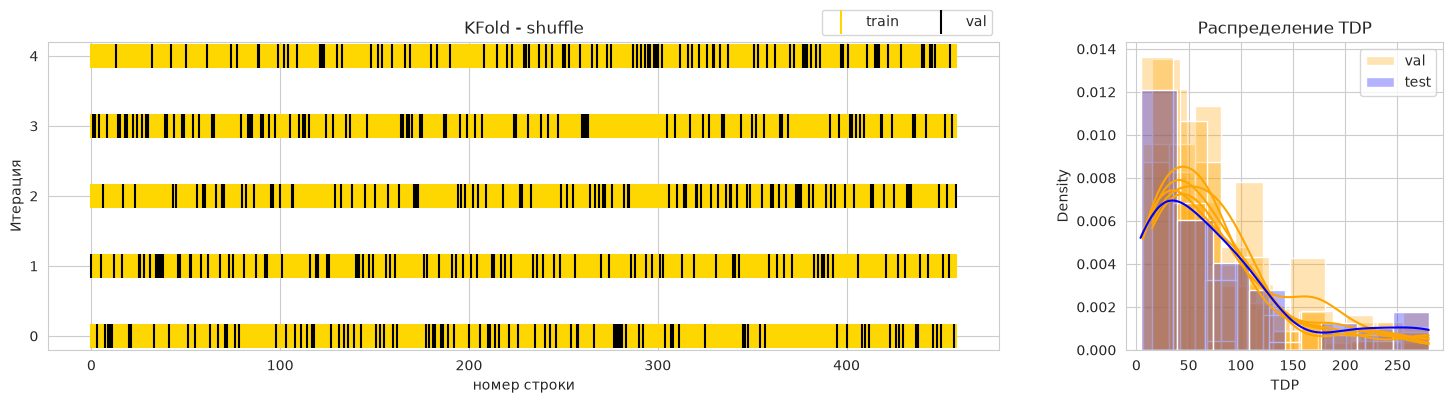

In [21]:
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
cv_name = 'KFold - shuffle'

res, splits = cross_validation(cv, cv_name, X_train, y_train, cv_results)
plot_cv(splits, y_train, cv_name)

### 3. StratifiedKFold

Stratified KFold

    RMSE    MAE    R2  TEST_RMSE
0  31.35  18.95  0.72      38.33
1  30.75  21.19  0.76      37.90
2  32.83  22.41  0.75      37.56
3  30.82  23.96  0.79      37.45
4  27.29  19.92  0.80      38.01

       RMSE    MAE    R2  TEST_RMSE
mean  30.61  21.29  0.76      37.85
std    1.82   1.77  0.03       0.32


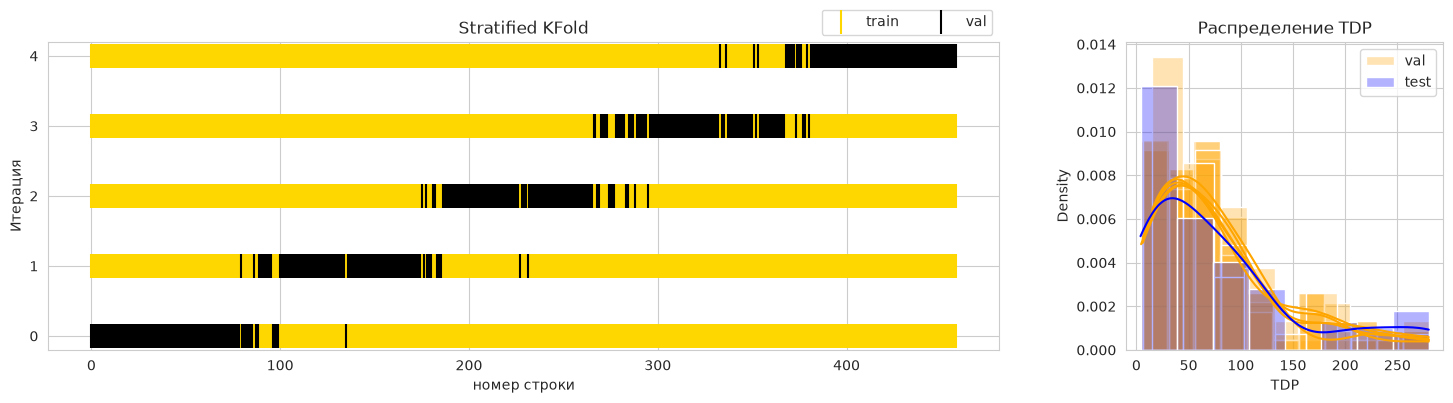

In [ ]:
from sklearn.model_selection import StratifiedKFold
import numpy as np

bins = np.quantile(y_train, [0, 0.25, 0.5, 0.75, 1.0])
y_binned = np.digitize(y_train, bins)

cv = StratifiedKFold(n_splits=5)
cv_name = 'Stratified KFold'

res, splits = cross_validation(cv, cv_name, X_train, y_train, cv_results, strat=y_binned)
plot_cv(splits, y_train, cv_name)

### 4. Group K-Fold

- family: Ryzen, A-series, EPYC...
- физическая закономерность, а не марка

GroupKFold

    RMSE    MAE    R2  TEST_RMSE
0  29.74  24.43  0.71      37.43
1  20.91  15.88  0.55      37.91
2  91.76  76.76 -3.27      42.49
3  37.74  23.98  0.70      37.64
4  56.59  42.34  0.50      41.01

       RMSE    MAE    R2  TEST_RMSE
mean  47.35  36.68 -0.16      39.30
std   25.14  21.83  1.56       2.06


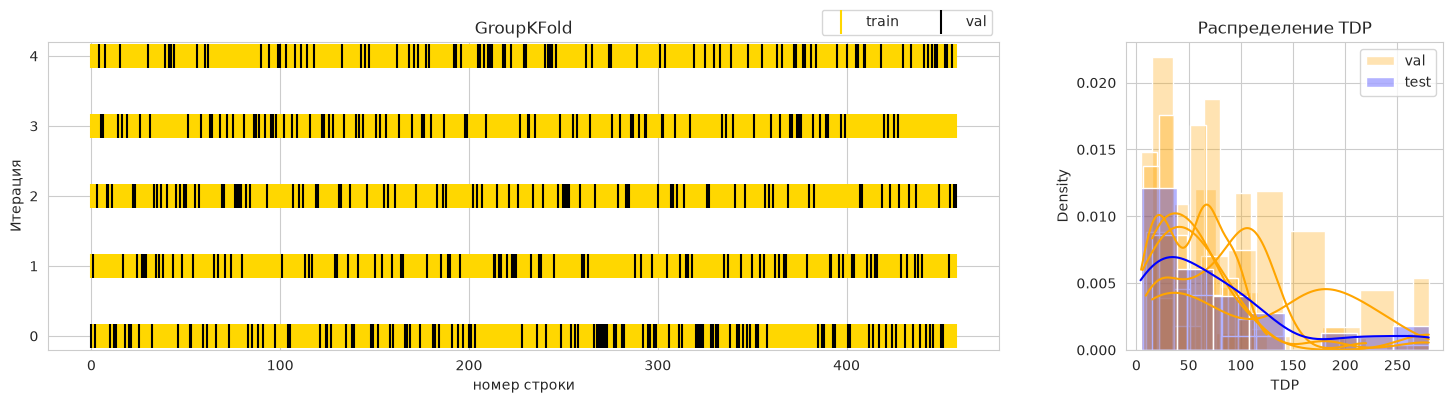

In [ ]:
from sklearn.model_selection import GroupKFold

groups = X_train['family']

cv = GroupKFold(n_splits=5)
cv_name = 'GroupKFold'

res, splits = cross_validation(cv, cv_name, X_train, y_train, cv_results, groups=groups)
plot_cv(splits, y_train, cv_name)

### 5. Grouped K-Fold with Random Permutation

GroupShuffleSplit

    RMSE    MAE    R2  TEST_RMSE
0  23.73  17.70  0.41      38.16
1  69.94  47.88 -0.90      42.80
2  32.67  25.96  0.67      38.05
3  90.13  71.30 -5.94      43.72
4  29.34  24.26  0.68      37.60

       RMSE    MAE    R2  TEST_RMSE
mean  49.16  37.42 -1.01      40.07
std   26.16  19.75  2.53       2.63


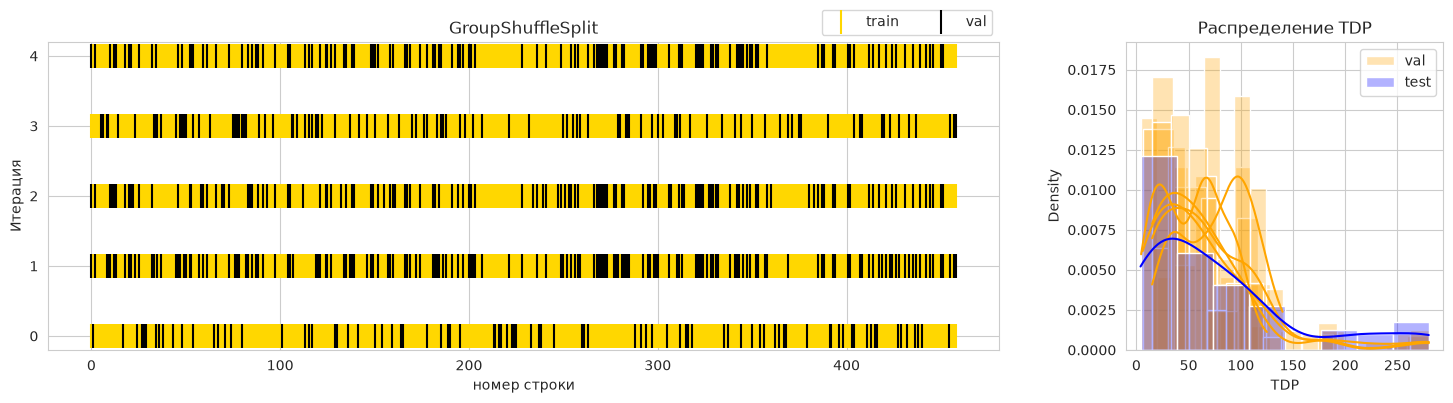

In [ ]:
from sklearn.model_selection import GroupShuffleSplit

groups = X_train['family']

cv = GroupShuffleSplit(n_splits=5, test_size=0.2, random_state=SEED)
cv_name = 'GroupShuffleSplit'

res, splits = cross_validation(cv, cv_name, X_train, y_train, cv_results, groups=groups)
plot_cv(splits, y_train, cv_name)

### 6. Leave-One-Out

LeaveOneGroupOut

      RMSE     MAE     R2  TEST_RMSE
0    23.68   23.68   0.00      37.69
1    17.66   12.84   0.60      37.68
2    17.50   13.29  -0.09      37.65
3    19.25   14.85   0.56      37.67
4    50.83   48.15  -3.18      37.94
5    78.40   71.35  -4.06      41.88
6    39.06   27.26   0.48      38.28
7   122.17  119.72 -12.62      43.24
8    18.46   11.81   0.49      37.64
9    30.67   28.02  -0.30      37.85
10   46.10   28.67   0.71      37.70
11   29.74   24.43   0.71      37.43
12   56.25   47.09 -30.64      37.74
13   32.77   31.91   0.00      37.71

       RMSE    MAE    R2  TEST_RMSE
mean  41.61  35.93 -3.38      38.44
std   28.06  28.17  8.31       1.71


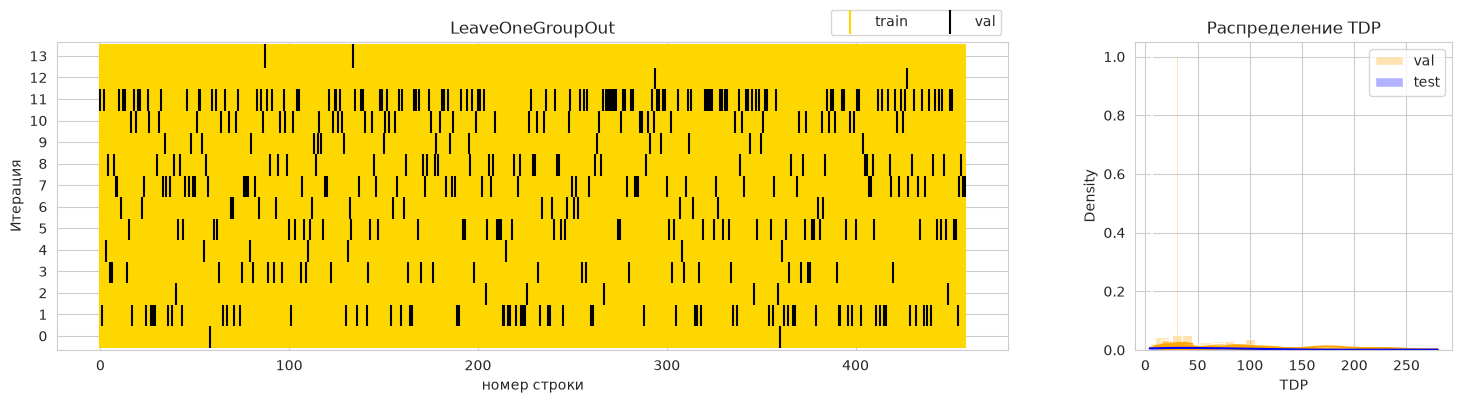

In [26]:
from sklearn.model_selection import LeaveOneGroupOut

groups = X_train['family']

cv = LeaveOneGroupOut()
cv_name = 'LeaveOneGroupOut'

res, splits = cross_validation(cv, cv_name, X_train, y_train, cv_results, groups=groups)
plot_cv(splits, y_train, cv_name)

Техника LeaveOneGroupOut показала, что линейная регрессия крайне плохо обобщается на неизвестные семейства процессоров. Некоторые итерации дают экстремально отрицательный R2, так как дисперсия TDP внутри одного семейства (например, мобильных чипов) стремится к нулю. А высокие значения RMSE (до 122 Вт) показывают, что модель не справляется с предсказанием TDP серверных архитектур, если обучалась только на десктопных/мобильных (или наоборот).
- жёлтая свечка это "все процессоры имеют один TDP", там была огромная плотность, поэтому график растянулся и стал плоским

### cv_results

In [ ]:
#todo
# cv_results - сюда автоматом идут результаты кроссвалидации для каждого метода, статы и выводы можно считать по ним
cv_results

{'KFold - no shuffle':         RMSE        MAE        R2  TEST_RMSE
 0  37.399270  31.062909  0.766371  38.156743
 1  27.237327  17.089946  0.753175  37.566743
 2  71.172253  56.473770 -2.942786  39.771316
 3  25.651327  17.680805  0.666764  37.947478
 4  42.728943  30.579073  0.717583  39.443706,
 'KFold - shuffle':         RMSE        MAE        R2  TEST_RMSE
 0  28.930403  21.002033  0.793297  38.147372
 1  30.524662  19.671196  0.728217  37.482690
 2  35.426371  23.363864  0.702397  38.038786
 3  31.244513  22.047598  0.739444  37.887359
 4  26.975353  19.817674  0.834871  37.378955}